# Random Forest — Full Deep Dive

In [ ]:
The Story First 📖

Remember Decision Tree problem?
→ one tree overfits easily
→ small data change = completely different tree
→ not stable!

Solution = Random Forest!

Instead of asking 1 person for advice
ask 100 people and take majority vote!

1 Doctor's opinion    = might be wrong
100 Doctors' opinions = much more reliable! ✅

That's exactly Random Forest!
100 Decision Trees → majority vote → final answer!

How Random Forest Works:

In [ ]:
Step 1 → Create N decision trees
          (default N=100)

Step 2 → Each tree gets:
          → random subset of data (rows)
          → random subset of features (columns)
          → so every tree is DIFFERENT!

Step 3 → Each tree makes prediction

Step 4 → Final answer:
          Classification → majority vote
          Regression     → average of all trees

Example with 5 trees:
Tree 1 → Bought
Tree 2 → Bought
Tree 3 → Not Bought
Tree 4 → Bought
Tree 5 → Bought

Majority = Bought ✅ (4 out of 5)

Why Random Forest is Better than Decision Tree:


In [ ]:
Decision Tree:

→ 1 tree
→ overfits easily
→ unstable (changes with data)
→ high variance

Random Forest:

→ 100+ trees
→ overfitting reduced! ✅
→ stable and reliable ✅
→ low variance ✅

Simple analogy:
Decision Tree = 1 student's answer
Random Forest = whole class votes!
Whole class is always more reliable! 😄

# Two Important Concepts:

Bagging (Bootstrap Aggregating):

Each tree gets random sample of data
WITH replacement

Example 10 samples:
[1,2,3,4,5,6,7,8,9,10]

Tree 1 gets: [1,3,3,5,7,7,9,10,2,4]  ← some repeated!
Tree 2 gets: [2,2,4,6,8,1,5,9,3,7]   ← different!
Tree 3 gets: [5,5,1,8,3,6,2,9,4,10]  ← different!

Every tree sees different data!
→ every tree learns differently!
→ reduces overfitting! ✅

Feature Randomness:


In [ ]:
Each tree only sees random subset of features

Example 4 features: age, salary, gender, city

Tree 1 sees: age, salary
Tree 2 sees: salary, city
Tree 3 sees: age, gender

→ trees are more diverse!
→ reduces correlation between trees!
→ better final prediction! ✅

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# data
data = {
    "age"    : [22,25,47,52,46,56,55,60,62,61,
                18,28,27,29,49,55,25,58,19,40],
    "salary" : [15,18,60,80,55,90,85,95,100,98,
                12,20,22,25,65,88,19,92,14,45],
    "bought" : [0,0,1,1,1,1,0,1,1,1,
                0,0,0,0,1,1,0,1,0,1]
}

df= pd.DataFrame(data)

X=df[["age","salary"]]
y=df["bought"]

X_train, X_test, y_train, y_test = train_test_split(
                        X, y, test_size=0.2, random_state=42)

# create model — parameters explained below!



model= RandomForestClassifier(
                n_estimators=100, # number of trees
                criterion="gini",
                max_depth=3, # split quality measure
                min_samples_leaf=1,# min samples in leaf
                min_samples_split=2,# max depth of each tree
                max_features='sqrt',# features per tree
                bootstrap=True, # use bagging
                random_state=42,
                n_jobs=-1# use all CPU cores!
)

model.fit(X_train,y_train)
y_pred= model.predict(X_test)

# check overfitting

train_acc= accuracy_score(y_train,model.predict(X_train))
test_acc=accuracy_score(y_test,y_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc)
print("Difference    :", round(train_acc-test_acc, 2))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Train Accuracy: 1.0
Test Accuracy : 1.0
Difference    : 0.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



# Parameters Explained

In [ ]:
n_estimators=100:

number of decision trees in forest

n_estimators=10  → 10 trees  (fast but less accurate)
n_estimators=100 → 100 trees (balanced ✅ default)
n_estimators=500 → 500 trees (slow but accurate)

More trees = more stable BUT slower!
100 is good starting point ✅

In [ ]:
max_features="sqrt":

how many features each tree sees

"sqrt" → √total features (default for classification)
         4 features → each tree sees √4 = 2 features

"log2" → log2(total features)
         4 features → each tree sees log2(4) = 2

None   → all features (removes randomness!)

sqrt is best default! ✅

In [ ]:
bootstrap=True:

True  → each tree gets random sample WITH replacement
        (bagging!) ✅ default

False → each tree sees full dataset
        (removes randomness, not recommended!)

In [ ]:
n_jobs=-1:

how many CPU cores to use

n_jobs=1  → use 1 core (slow)
n_jobs=-1 → use ALL cores (fast!) ✅

Always use -1 for faster training!

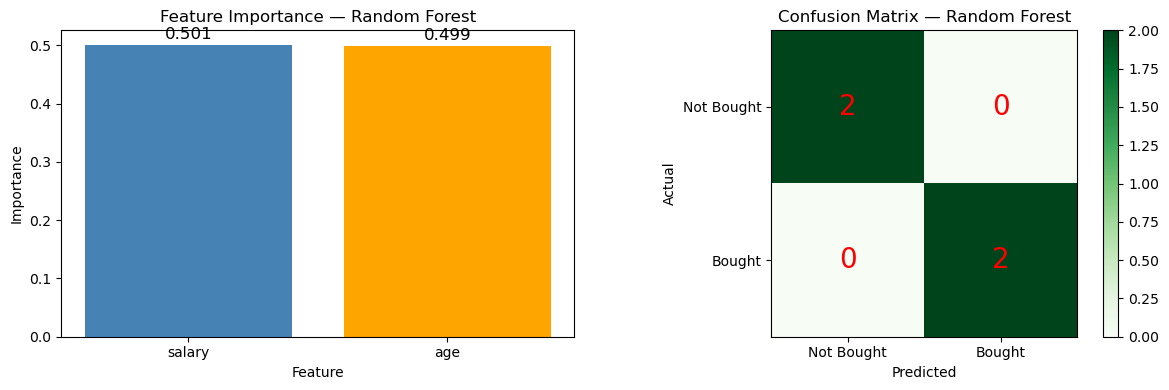

In [10]:
plt.figure(figsize=(12, 4))

# Plot 1 — Feature Importance
plt.subplot(1, 2, 1)
importance = pd.DataFrame({
    "feature"   : ["age", "salary"],
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

plt.bar(importance["feature"],
        importance["importance"],
        color=["steelblue", "orange"])
plt.title("Feature Importance — Random Forest")
plt.xlabel("Feature")
plt.ylabel("Importance")

# add values on bars
for i, v in enumerate(importance["importance"]):
    plt.text(i, v + 0.01, f"{v:.3f}",
             ha="center", fontsize=12)

# Plot 2 — Confusion Matrix
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, cmap="Greens")
plt.colorbar()
plt.title("Confusion Matrix — Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1], ["Not Bought", "Bought"])
plt.yticks([0,1], ["Not Bought", "Bought"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j],
                ha="center", va="center",
                color="red", fontsize=20)
plt.tight_layout()
plt.show()

In [ ]:
Decision Tree vs Random Forest:
                Decision Tree   Random Forest
────────────────────────────────────────────
Trees           1               100+
Overfitting     High ❌          Low ✅
Stability       Low ❌           High ✅
Speed           Fast ✅          Slower ❌
Interpretable   Yes ✅           No ❌
Feature Import  Yes ✅           Yes ✅
Accuracy        Lower           Higher ✅

In [ ]:
Notes Summary 📝

Random Forest:
→ collection of many decision trees
→ each tree sees random data + random features
→ final answer = majority vote

Why better than Decision Tree:
→ reduces overfitting ✅
→ more stable ✅
→ higher accuracy ✅

Key Parameters:
→ n_estimators  = number of trees (100 default)
→ max_features  = features per tree (sqrt default)
→ max_depth     = depth of each tree
→ bootstrap     = bagging on/off
→ n_jobs=-1     = use all CPU cores

When to use Random Forest:
→ when Decision Tree overfits
→ when you need higher accuracy
→ when data is large and complex

Disadvantage:
→ slower than single tree
→ hard to visualize/interpret
→ black box model!